# Bayesian Uncertainty Minimization

This demo shows how to minimize the uncertainty of a simple 1D function using Bayesian optimization with a GPR as the surrogate model. The GPR can use derivative information to aid in the regression.

In [1]:
import sys 
import numpy as np
import matplotlib.pyplot as plt
import time
import copy

sys.path.append("../..")
import gpder 
from gpder import UncertaintyOptimization
from gpder.bayes.minimizers import hybrid_minimizer

from gpder.gaussian_process import GaussianProcessRegressor
from gpder.gaussian_process.kernels import GPKernelDerAware, GPKernel

from sklearn.metrics import mean_squared_error

from utils import plot_gpr_evolution, plot_gpr_iterloss
from utils import grid_sampling


We regress the same function as in the 'Gaussian Process' demo, but instead of randomly selecting training points for the GPR, we rely on a Bayesian optimization to find the training points which minimize the uncertainty of the model.

In [2]:
def F(X, s=0.1):
    noise = s * np.random.uniform(-1, 1)
    return X * np.sin(4*np.pi * X**2) + s

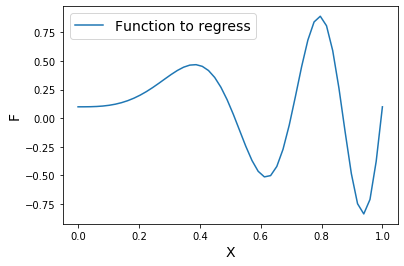

In [3]:
np.random.seed(1)

X_lower = 0 
X_upper = 1
X_star = np.linspace(X_lower, X_upper, 50)
y_star = F(X_star)

plt.plot(X_star, y_star, label='Function to regress')
plt.xlabel("X", fontsize=14)
plt.ylabel("F", fontsize=14)
plt.legend(fontsize=14)
plt.show()

In [4]:
def dF(X, s=0.1):
    noise = s * np.random.uniform(-1, 1)
    return np.sin(4*np.pi * X**2) + X * np.cos(4*np.pi * X**2) * (8*np.pi * X) + s

Using only the cov_yy

| Iter | X          | Target     | MSE test   | Uncert test|
| 1    | 0.696469   | -0.029909  | 0.177286   | 2.304318   |
| 2    | 0.286139   | 0.345142   | 0.177286   | 2.304318   |
| 3    | 0.226851   | 0.236688   | 0.177286   | 2.304318   |
| 4    | 0.551315   | -0.245775  | 0.177286   | 2.304318   |
| 5    | 0.719469   | 0.258144   | 0.177286   | 2.304318   |
| 6    | 1.000000   | 0.100000   | 0.009647   | 4.084409   |
| 7    | 0.156457   | 0.147372   | 0.016336   | 1.106047   |
| 8    | 0.451014   | 0.349209   | 0.001795   | 0.579777   |
| 9    | 0.811644   | 0.839666   | 0.003926   | 0.416523   |
| 10   | 0.079144   | 0.106223   | 0.001117   | 0.011397   |
| 11   | 0.000000   | 0.100000   | 0.001053   | 0.002661   |
| 12   | 0.950624   | -0.789522  | 0.000003   | 0.001426   |
| 13   | 0.671732   | -0.286429  | 0.000003   | 0.001266   |


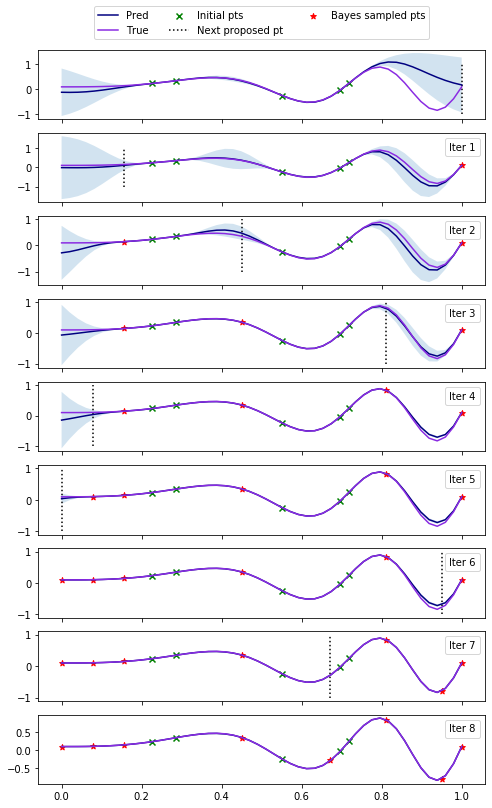

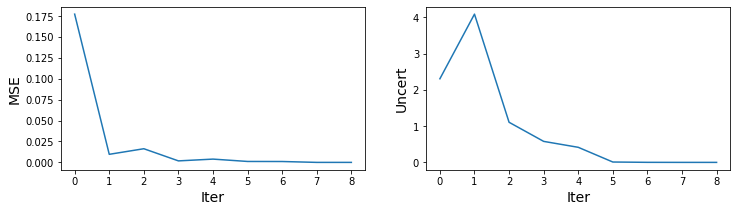

In [5]:
bayes_der = UncertaintyOptimization(fun=F,
                                    dfun=dF,
                                    verbose=True,
                                    param_bounds={'X': (0, 1)},
                                    ignore_convergence_warnings=True,
                                    random_state=123)

bayes_der.minimize_uncertainty(nrand_train=5,
                           params_test=X_star.reshape(-1, 1),
                           niters=8,
                           minimizer_restarts=5,
                           gp_optimizer_restarts=10)

der_mse = bayes_der.mse_test
der_uncert = bayes_der.uncert_test

plot_gpr_evolution(bayes=copy.deepcopy(bayes_der), 
                   save_to="der_gpr_evol.png")
plot_gpr_iterloss(der_mse, der_uncert,
                  save_to="der_metricsvsiter.png")